## Importing Libraries

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

Training dataset preprocessing

In [6]:
training_set = tf.keras.utils.image_dataset_from_directory(
    './train_images/',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 70296 files belonging to 38 classes.


Validation set preprocessing

In [7]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [8]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [9]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[110.5  101.5  106.5 ]
   [123.5  114.5  119.5 ]
   [127.   118.   123.  ]
   ...
   [142.5  133.5  136.5 ]
   [141.75 132.75 135.75]
   [144.25 135.25 138.25]]

  [[123.   114.   119.  ]
   [125.5  116.5  121.5 ]
   [124.   115.   120.  ]
   ...
   [142.   133.   136.  ]
   [141.25 132.25 135.25]
   [141.25 132.25 135.25]]

  [[121.75 112.75 117.75]
   [121.5  112.5  117.5 ]
   [124.25 115.25 120.25]
   ...
   [143.75 134.75 137.75]
   [142.   133.   136.  ]
   [143.   134.   137.  ]]

  ...

  [[122.   114.   112.  ]
   [124.5  116.5  114.5 ]
   [124.5  116.5  114.5 ]
   ...
   [167.5  158.5  161.5 ]
   [163.5  154.5  157.5 ]
   [164.75 155.75 158.75]]

  [[120.75 112.75 110.75]
   [121.75 113.75 111.75]
   [120.5  112.5  110.5 ]
   ...
   [159.   150.   153.  ]
   [157.75 148.75 151.75]
   [162.75 153.75 156.75]]

  [[125.   117.   115.  ]
   [123.75 115.75 113.75]
   [122.   114.   112.  ]
   ...
   [160.75 151.75 154.75]
   [165.75 156.75 159.75]
   [164.25 155.25 15

## Building Model

In [10]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [28]:
model = Sequential()

### Building Convolution layer

In [29]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [30]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [31]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [32]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [33]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [34]:
model.add(Dropout(0.25))

In [35]:
model.add(Flatten())

In [36]:
model.add(Dense(units=1500,activation='relu'))

In [37]:
model.add(Dropout(0.4))

In [38]:
## Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model


In [39]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │    12,289,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,058,762 (65.07 MB)

 Trainable params: 17,058,762 (65.07 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [41]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3989s 2s/step - accuracy: 0.4547 - loss: 1.9733 - val_accuracy: 0.8712 - val_loss: 0.4020
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3221s 1s/step - accuracy: 0.8683 - loss: 0.4154 - val_accuracy: 0.9220 - val_loss: 0.2356
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3191s 1s/step - accuracy: 0.9200 - loss: 0.2522 - val_accuracy: 0.9392 - val_loss: 0.1913
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3187s 1s/step - accuracy: 0.9460 - loss: 0.1639 - val_accuracy: 0.9524 - val_loss: 0.1449
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3022s 1s/step - accuracy: 0.9596 - loss: 0.1245 - val_accuracy: 0.9608 - val_loss: 0.1195
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2628s 1s/step - accuracy: 0.9655 - loss: 0.1008 - val_accuracy: 0.9634 - val_loss: 0.1124
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2677s 1s/step - accuracy: 0.9751 - loss: 0.0767 - val_accuracy: 0.9637 - val_loss: 0.1195
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2629s 1s/step - accuracy: 0.9786 -

In [42]:
Train_loss,Train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 655s 298ms/step - accuracy: 0.9873 - loss: 0.0620


In [46]:
print(Train_loss,Train_acc)

0.06044116988778114 0.9878227710723877


### Saving Model

In [45]:
model.save('trained_model.keras')

In [47]:
training_history.history

{'accuracy': [0.6581833958625793,
  0.8876449465751648,
  0.9283021688461304,
  0.9507930874824524,
  0.9616900086402893,
  0.9690447449684143,
  0.9755316972732544,
  0.9793015122413635,
  0.9821040034294128,
  0.9835123419761658],
 'loss': [1.1683430671691895,
  0.35090208053588867,
  0.2208075225353241,
  0.1501350700855255,
  0.11671634018421173,
  0.09182921797037125,
  0.07456601411104202,
  0.06285684555768967,
  0.05342044308781624,
  0.05072769522666931],
 'val_accuracy': [0.8711586594581604,
  0.9220350384712219,
  0.9391645789146423,
  0.9523674249649048,
  0.9607899188995361,
  0.9634076952934265,
  0.9637491703033447,
  0.9619849920272827,
  0.9738789200782776,
  0.9627248048782349],
 'val_loss': [0.40199995040893555,
  0.23555877804756165,
  0.19132265448570251,
  0.14490501582622528,
  0.11950360983610153,
  0.11243543773889542,
  0.11951358616352081,
  0.12189376354217529,
  0.08599907904863358,
  0.1552589237689972]}

In [48]:
# Recording History in json

import json
with open('training_hist.json','w') as f:
    json.dump(training_history.history,f)

# Accuracy Visualization

In [50]:
epochs = [i for i in range(1,11)]
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

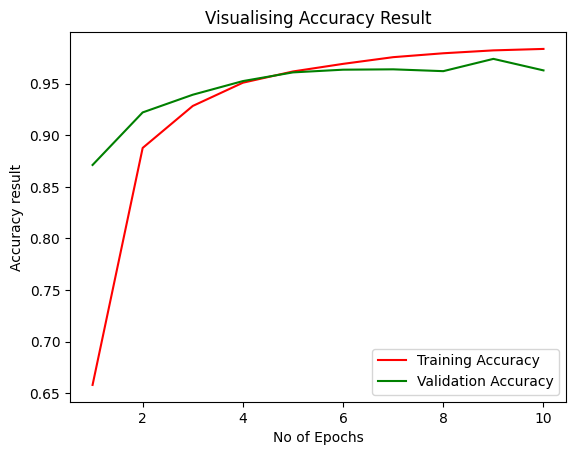

In [60]:
plt.plot(epochs,training_history.history['accuracy'],color = 'red', label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color = 'green', label='Validation Accuracy')
plt.xlabel('No of Epochs')
plt.ylabel('Accuracy result')
plt.title("Visualising Accuracy Result")
plt.legend()
plt.show()

### Precesion,Recall and F1 Score

In [22]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [23]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [24]:
from tensorflow.keras.models import load_model
loaded_model = load_model('trained_model.keras')

/Users/vivekdesai/anaconda3/envs/tensorflow_env/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 26 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
y_pred = loaded_model.predict(test_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 167s 304ms/step


In [27]:
y_pred,y_pred.shape

(array([[1.0000000e+00, 2.3077234e-08, 2.6288704e-12, ..., 2.6841106e-17,
         1.7261387e-15, 1.1997769e-13],
        [1.0000000e+00, 2.3382910e-08, 5.6657647e-11, ..., 7.8530054e-18,
         1.9214498e-15, 6.4118880e-16],
        [9.9999917e-01, 3.1992581e-08, 3.6245305e-11, ..., 6.3528419e-16,
         1.6213959e-14, 2.6531227e-12],
        ...,
        [1.8690826e-12, 3.2265495e-15, 4.1072833e-11, ..., 6.6235476e-14,
         1.6434330e-16, 9.9999988e-01],
        [5.6227672e-11, 2.5216160e-15, 2.3540166e-11, ..., 7.1247795e-12,
         2.3658398e-16, 1.0000000e+00],
        [1.9537883e-13, 3.9791838e-15, 3.1408697e-13, ..., 9.4143265e-16,
         4.5286878e-13, 9.9999988e-01]], dtype=float32),
 (17572, 38))

In [28]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [29]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

2024-12-19 15:30:04.747989: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [30]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [34]:
from sklearn.metrics import classification_report,confusion_matrix

In [32]:
print(classification_report(y_true , predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.98      0.96       504
                                 Apple___Black_rot       0.94      0.99      0.97       497
                          Apple___Cedar_apple_rust       0.85      1.00      0.92       440
                                   Apple___healthy       0.97      0.96      0.97       502
                               Blueberry___healthy       0.90      0.99      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.93      1.00      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.96      0.93       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.95      0.

In [42]:
cm = confusion_matrix(y_true,predicted_categories)
cm


array([[494,   2,   0, ...,   0,   0,   0],
       [  0, 492,   1, ...,   0,   0,   0],
       [  0,   0, 439, ...,   0,   0,   0],
       ...,
       [  0,   0,   1, ..., 479,   0,   0],
       [  3,   1,   5, ...,   0, 419,   0],
       [  0,   0,   0, ...,   0,   0, 468]])

### CONFUSION MATRIX VISUALISATION

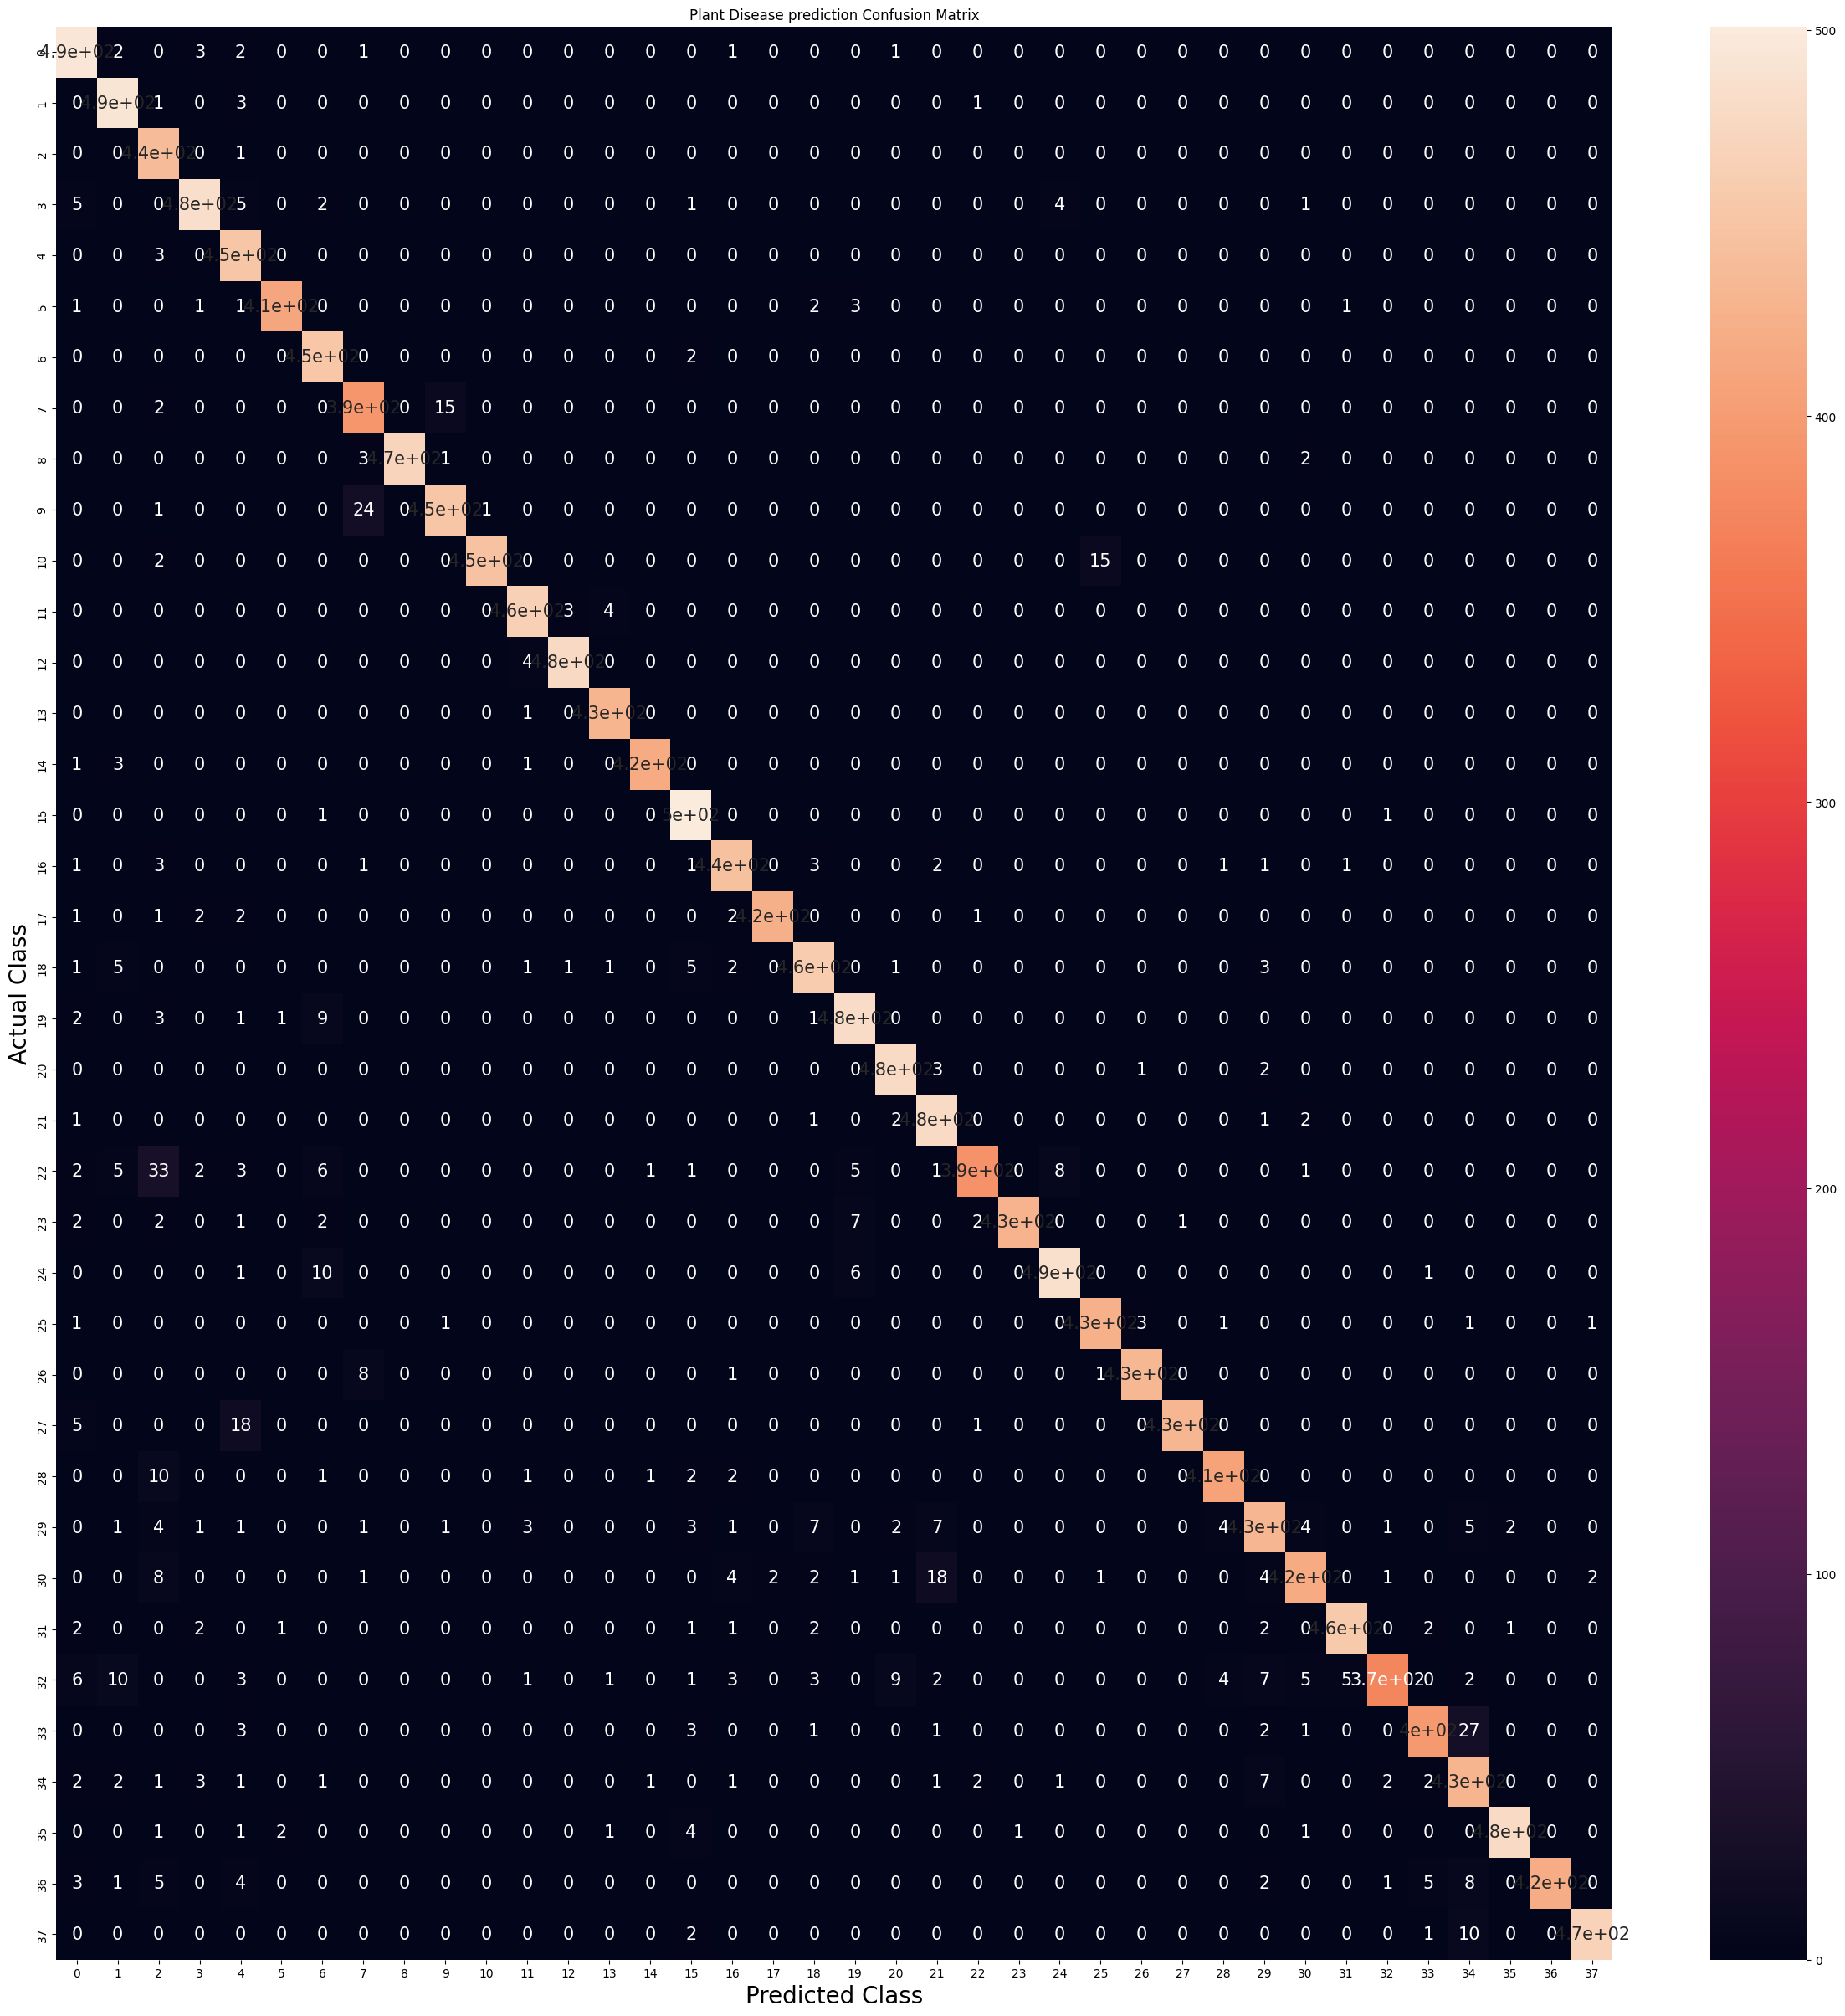

In [57]:
plt.figure(figsize=(30,30))
sns.heatmap(cm,annot=True,annot_kws={'size':15})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease prediction Confusion Matrix")
plt.show()